In [ ]:
import random
from importlib import reload

import common

reload(common)
from common import priority_topological_sort


In [ ]:
def sorted_dag(
    vs: list[int],  # 頂点のリスト
    graph: dict[int, list[int]],  # 隣接リスト
    graph_r: dict[int, list[int]],  # 逆グラフ
    initial_ranking: list[int],  # 初期のランク
):
    """閉路を含むDAGを初期のランクに従ってソートする"""
    label_num, group = scc(graph, graph_r, vs)
    ssc_graph, belong_lists = scc_construct(graph, label_num, group, vs)

    num_to_ranking = {i: j for j, i in enumerate(initial_ranking)}
    construct_initial_ranking = {}
    for i, belong_list in enumerate(belong_lists):
        ssc_ranks = [num_to_ranking[v] for v in belong_list]
        n = len(ssc_ranks)
        mid_rank = sorted(ssc_ranks)[n // 2]
        construct_initial_ranking[i] = mid_rank

    result_rank_construct = priority_topological_sort(ssc_graph, construct_initial_ranking)
    result_rank = []
    for i in result_rank_construct:
        now_belong = belong_lists[i]
        result_rank.extend(now_belong)

    return result_rank

In [ ]:
random.seed(1)
constraints = []

for _ in range(16):
    v1 = random.randint(50, 60)
    v2 = random.randint(50, 60)
    if v1 == v2:
        continue
    constraints.append((v1, v2))

vs = set()
for u, v in constraints:
    vs.add(u)
    vs.add(v)
vs = list(vs)

initial_ranking = sorted(vs, key=lambda x: random.random())
scc_graph, graph_r = construct_dag_from_edges(constraints, vs)

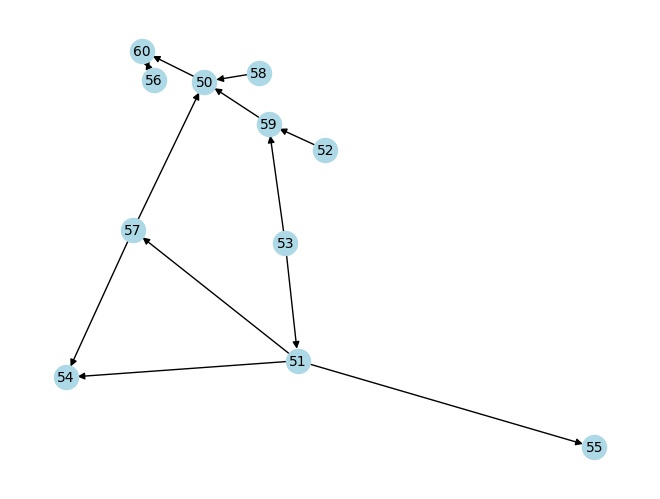

In [313]:
import networkx as nx

nx_graph = nx.DiGraph(constraints)

nx.draw(nx_graph, nx.spring_layout(nx_graph), with_labels=True, node_color="lightblue", node_size=300, font_size=10)